In [1]:
%reload_ext autoreload
%autoreload 2

In Terminal all the time
cd ~/Desktop/Thesis
source venvs/thesis_rocm/bin/activate

cd /home/virthian/Desktop/Thesis/Package/my_package/autoseqmodels
pip install -e .

In [2]:
# Standard library
import gc
import importlib
import os
import sys
from pathlib import Path

# Data / numerical work
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt

# Machine learning utilities
from sklearn.model_selection import train_test_split

# Deep learning
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

# Metrics / optimization / progress
import torchmetrics
import optuna
import json
from tqdm.auto import tqdm
from Models.optuna_tuning import run_optuna_study

# Your package: data preparation
from autoseqmodels.data_prep import loader, inspection, encoders, sequence_builder

from autoseqmodels.data_prep.inspection import (
    infer_column_types,
    propose_structure,
    classify_time_variance,
    plan_covariates,
    CovariatePlan,
)
from autoseqmodels.data_prep.loader import _coerce_merge_key
# Your package: models / training
from autoseqmodels.models import (
    training,
    sequence_lstm,
    sequence_transformer,
)
from Models import (
    MultinomialLSTMModel, InferenceMultinomialLSTMModel,
    MultinomialTransformerModel, InferenceMultinomialTransformerModel,
    fit_model, run_monte_carlo_forecast, compute_metrics,
    save_predictions_to_csv,
)

from Data_preparation import(
    dynamic_panel_dataset
)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

ImportError: cannot import name 'run_monte_carlo_forecast' from 'Models' (/home/virthian/Desktop/Thesis/Package_Notebook/Models/__init__.py)

# Data Loading


In [ ]:
csv_path = "Datasets/Dataset_clean/electronics_customer_week_panel.csv"

DATA_CONFIG = {
				"id_col":           "Id",
				"clip_target_upper": 							6,
				"target_col":       "Transactions",
				"time_cols":        ["year", "week"],   # weekly: year + week
				"frequency":        "weekly",
				"periods_per_year": 52,
				"training_start":   "1999-01-01",
				"training_end":     "2000-12-31",
				"holdout_start":    "2001-01-01",
				"holdout_end":      "2001-12-31",
}

# ---- Step 2: which engineered time features to create ---------------
TIME_FEATURES = {
				"add_year_idx":          True,
				"add_week_sin_cos":      True,
				"add_month_sin_cos":     False,
				"add_dayofyear_sin_cos": False,
}

# What columns will be used, if not her or input_spec, they are dropped.
FEATURE_SCHEMA_FULL = {
				"target":                            ["Transactions"],
				"time":                              ["week_sin", "week_cos"],
				"static_covariates":                 ["Gender", "Income"],
				"known_future_time_varying_inputs":  ["year_idx", "high.season"],
				"observed_past_time_varying_inputs": [],
}

# Controls what is embeded
INPUT_SPEC = {
				"embedded_cols": {
								"Transactions": 7, # Need to be bigger than the clipping
								"Gender":       2,
				}
}


In [ ]:
# ---- 1. Build the (N, T, F) arrays from your config ----------------------
panel     = pd.read_csv(csv_path)

data_full = dynamic_panel_dataset.prepare_dataset(
    panel, DATA_CONFIG, FEATURE_SCHEMA_FULL, TIME_FEATURES,
)

# ---- 2. Shape tensors for fit_model --------------------------------------
# samples : (N, T-1, F) float32
# targets : fit_model wants (B, T) long with values in [0, max_trans)
X = data_full["samples"]
y = data_full["targets"].squeeze(-1).astype(np.int64)

max_trans = INPUT_SPEC["embedded_cols"]["Transactions"]
assert y.min() >= 0 and y.max() < max_trans, (
    f"Transactions in [{y.min()}, {y.max()}] but INPUT_SPEC caps at {max_trans-1}. "
    f"Raise the cardinality or clip the panel."
)

# ---- 3. Customer-wise train/val split -----------------------------------
train_idx, val_idx = train_test_split(
    np.arange(data_full["N"]), test_size=0.2, random_state=42,
)
# train_loader = DataLoader(
#     TensorDataset(torch.from_numpy(X[train_idx]), torch.from_numpy(y[train_idx])),
#     batch_size=128, shuffle=True,
# )
# val_loader = DataLoader(
#     TensorDataset(torch.from_numpy(X[val_idx]), torch.from_numpy(y[val_idx])),
#     batch_size=128, shuffle=False,
# )


N=829 T_CAL=104 T_HOLD=52 F=7
seq_cols   = ['Transactions', 'week_sin', 'week_cos', 'year_idx', 'high.season', 'Gender', 'Income']
target_col = 'Transactions' at index 0
calibration (829, 104, 7) | samples (829, 103, 7) | targets (829, 103, 1) | holdout (829, 52, 7)


## Optuna feature enginnering 

### LSTM with Optuna

In [ ]:
# ---- 4. Optuna data_builder ----------------------------------------------
# Closes over X, y, train_idx, val_idx, data_full, INPUT_SPEC from the cell
# above. `feature_config` is sampled by the search but ignored here —
# the schema/INPUT_SPEC are already fixed for this study.
def data_builder(feature_config, batch_size):
    tr_loader = DataLoader(
        TensorDataset(torch.from_numpy(X[train_idx]), torch.from_numpy(y[train_idx])),
        batch_size=batch_size, shuffle=True,
    )
    va_loader = DataLoader(
        TensorDataset(torch.from_numpy(X[val_idx]),   torch.from_numpy(y[val_idx])),
        batch_size=batch_size, shuffle=False,
    )
    metadata = {
        "seq_cols":   data_full["seq_cols"],
        "input_spec": INPUT_SPEC,
        "target_col": data_full["target_col"],
        "seq_len":    X.shape[1],         # used by the transformer's mask cache
    }
    return tr_loader, va_loader, metadata


# ---- 5. Run the LSTM study -----------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

lstm_study = run_optuna_study(
    model_type="lstm",
    data_builder=data_builder,
    data_info={
        "n_epochs":       100,
        "patience":       5,
        "checkpoint_dir": "./checkpoints/lstm_optuna",
        "verbose":        False,
    },
    device=device,
    n_trials=100,
    study_name="lstm_full_schema",
    summary_dir="./optuna_summaries",
)

print("best trial   :", lstm_study.best_trial.number)
print("best val loss:", lstm_study.best_trial.value)
print("best params  :", lstm_study.best_trial.params)
print("checkpoint   :", lstm_study.best_trial.user_attrs["checkpoint_path"])

[I 2026-05-20 20:06:39,479] A new study created in memory with name: lstm_full_schema
[I 2026-05-20 20:06:53,735] Trial 0 finished with value: 0.1514586607615153 and parameters: {'hidden_dim': 128, 'memory_units': 32, 'dense_units': 64, 'num_layers': 2, 'dropout': 0.008233797718320978, 'learning_rate': 0.002708160864249967, 'weight_decay': 0.002136832907235877, 'batch_size': 64, 'use_rfm': False, 'use_rolling': True, 'use_calendar': True, 'use_cluster': False, 'use_static': False}. Best is trial 0 with value: 0.1514586607615153.
[I 2026-05-20 20:07:05,637] Trial 1 finished with value: 0.16246354579925537 and parameters: {'hidden_dim': 256, 'memory_units': 64, 'dense_units': 128, 'num_layers': 2, 'dropout': 0.12184550766934828, 'learning_rate': 0.00013940346079873228, 'weight_decay': 0.0005456725485601478, 'batch_size': 256, 'use_rfm': False, 'use_rolling': False, 'use_calendar': False, 'use_cluster': True, 'use_static': True}. Best is trial 0 with value: 0.1514586607615153.
[I 2026-05-

best trial   : 4
best val loss: 0.14406558126211166
best params  : {'hidden_dim': 64, 'memory_units': 32, 'dense_units': 128, 'num_layers': 2, 'dropout': 0.2533615026041694, 'learning_rate': 0.0019375501864120402, 'weight_decay': 0.0016394127471631608, 'batch_size': 128, 'use_rfm': False, 'use_rolling': True, 'use_calendar': False, 'use_cluster': False, 'use_static': False}
checkpoint   : checkpoints/lstm_optuna/lstm_trial_4.pth


### Transformer with Optuna

In [6]:
tx_study = run_optuna_study(
    model_type="transformer",
    data_builder=data_builder,
    data_info={
        "n_epochs":       100,
        "patience":       5,
        "checkpoint_dir": "./checkpoints/tx_optuna",
        "verbose":        False,
    },
    device=device,
    n_trials=100,
    study_name="transformer_full_schema",
    summary_dir="./optuna_summaries",
)

[I 2026-05-20 20:10:32,179] A new study created in memory with name: transformer_full_schema
/home/virthian/Desktop/Thesis/venvs/thesis_rocm/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
[I 2026-05-20 20:10:36,663] Trial 0 finished with value: 0.15294138342142105 and parameters: {'d_model': 64, 'nhead': 2, 'num_encoder_layers': 1, 'dropout': 0.3464704583099741, 'learning_rate': 0.0007725378389307352, 'weight_decay': 0.0006796578090758161, 'batch_size': 128, 'use_rfm': True, 'use_rolling': False, 'use_calendar': True, 'use_cluster': False, 'use_static': False}. Best is trial 0 with value: 0.15294138342142105.
/home/virthian/Desktop/Thesis/venvs/thesis_rocm/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first 

## Training + Predicting 

In [7]:
# Per-customer calibration: list of DataFrames in seq_cols order.
calibration_dfs = [
    pd.DataFrame(data_full["calibration"][i], columns=data_full["seq_cols"])
    for i in range(data_full["N"])
]

# Holdout calendar = one row per holdout step, with the calendar-driven
# columns from seq_cols. Take any customer's holdout slice (these columns
# are identical across customers per step) and drop the rest.
id_col           = DATA_CONFIG["id_col"]
first_id         = data_full["ids"][0]
holdout_panel    = data_full["holdout_panel"]
calendar_cols    = ["week_sin", "week_cos", "year_idx"]
holdout_calendar = (
    holdout_panel[holdout_panel[id_col] == first_id]
    .sort_values(["year", "week"])[calendar_cols]
    .reset_index(drop=True)
)
print(holdout_calendar.head())

   week_sin  week_cos  year_idx
0  0.000000  1.000000         2
1  0.120537  0.992709         2
2  0.239316  0.970942         2
3  0.354605  0.935016         2
4  0.464723  0.885456         2


In [8]:
from utils.main_plot import compute_and_save_lstm

p = lstm_study.best_trial.params
ckpt = lstm_study.best_trial.user_attrs["checkpoint_path"]

compute_and_save_lstm(
    checkpoint_path=ckpt,
    calibration=calibration_dfs,
    holdout_calendar=holdout_calendar,
    seq_cols=data_full["seq_cols"],
    input_spec=INPUT_SPEC,
    target_col=data_full["target_col"],
    customer_ids=data_full["ids"],
    memory_units=p["memory_units"],
    dense_units=p["dense_units"],
    dropout=p["dropout"],
    n_simulations=100, batch_size=256, device=device,
)

RuntimeError: Error(s) in loading state_dict for InferenceMultinomialLSTMModel:
	size mismatch for backbone._emb_modules.0.2.weight: copying a param with shape torch.Size([64, 3]) from checkpoint, the shape in current model is torch.Size([128, 3]).
	size mismatch for backbone._emb_modules.0.2.bias: copying a param with shape torch.Size([64]) from checkpoint, the shape in current model is torch.Size([128]).
	size mismatch for backbone._emb_modules.0.3.weight: copying a param with shape torch.Size([64]) from checkpoint, the shape in current model is torch.Size([128]).
	size mismatch for backbone._emb_modules.0.3.bias: copying a param with shape torch.Size([64]) from checkpoint, the shape in current model is torch.Size([128]).
	size mismatch for backbone._emb_modules.1.2.weight: copying a param with shape torch.Size([64, 2]) from checkpoint, the shape in current model is torch.Size([128, 2]).
	size mismatch for backbone._emb_modules.1.2.bias: copying a param with shape torch.Size([64]) fr

In [ ]:
from utils.main_plot import compute_and_save_transformer

p = tx_study.best_trial.params
ckpt = tx_study.best_trial.user_attrs["checkpoint_path"]

compute_and_save_transformer(
    checkpoint_path=ckpt,
    calibration=calibration_dfs,
    holdout_calendar=holdout_calendar,
    seq_cols=data_full["seq_cols"],
    input_spec=INPUT_SPEC,
    target_col=data_full["target_col"],
    seq_len=X.shape[1],                  # same as during training
    customer_ids=data_full["ids"],
    d_model=p["d_model"],
    nhead=p["nhead"],
    num_encoder_layers=p["num_encoder_layers"],
    dropout=p["dropout"],
    n_simulations=100, batch_size=256, device=device,
)

/home/virthian/Desktop/Thesis/venvs/thesis_rocm/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
MC (transformer, sample): 100%|██████████| 100/100 [10:27<00:00,  6.27s/it]


PosixPath('/home/virthian/Desktop/Thesis/Package_Notebook/utils/Predictions/Transformer/predictions.csv')

### Pareto baseline

In [ ]:
from utils.main_plot import compute_and_save_pareto_nbd

compute_and_save_pareto_nbd(
    train_panel=data_full["train_panel"],
    holdout_length=data_full["T_HOLD"],
    id_col=DATA_CONFIG["id_col"],
    target_col=data_full["target_col"],
    time_col="period_start",
    period_in_days=7.0,           # weekly panel
    penalizer_coef=0.01,
    customer_ids=data_full["ids"],
)

/home/virthian/Desktop/Thesis/venvs/thesis_rocm/lib/python3.12/site-packages/scipy/optimize/_optimize.py:869: RuntimeWarning: invalid value encountered in subtract
  np.max(np.abs(fsim[0] - fsim[1:])) <= fatol):


PosixPath('/home/virthian/Desktop/Thesis/Package_Notebook/utils/Predictions/Pareto NBD/pareto_nbd_pred_20_05_19_42.csv')

            Valendin paper                                    Extra                               
                       mae mape_positive aggregate_bias_pct    rmse cumulative_mape aggregate_bias
model                                                                                             
Transformer        18.7100        1.2912             0.4663 21.9261          0.5499       671.4800
LSTM               12.3813        0.6378            -0.1156 16.0815          0.0839      -166.5100
Pareto/NBD         16.2961        0.5177            -0.5264 22.4636          0.5109      -758.0791


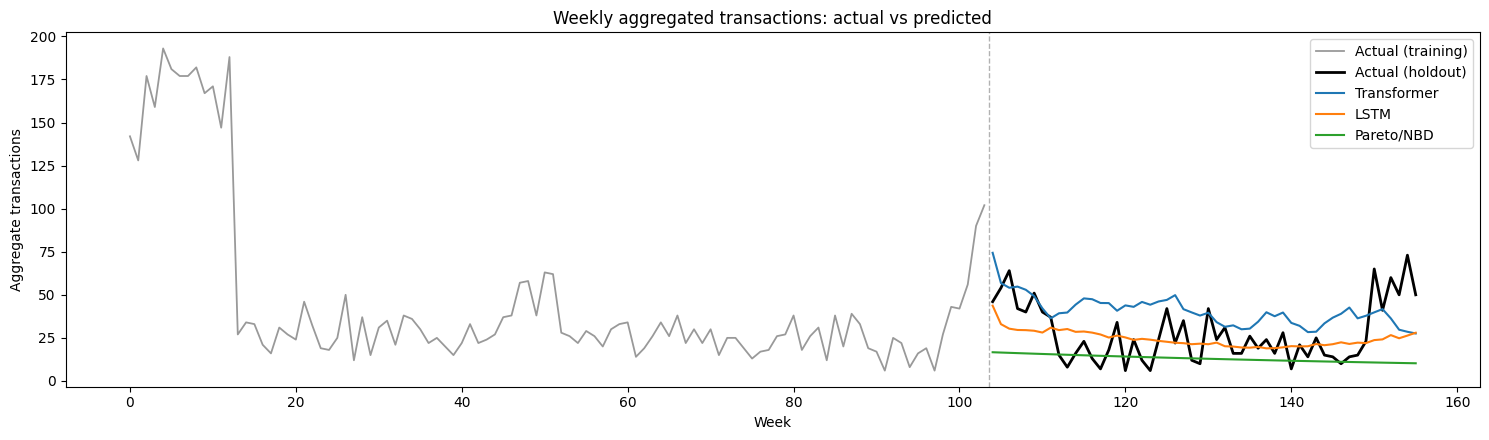

In [ ]:
from utils.main_plot import main as plot_main
# Build per-customer training DataFrames (same shape conversion as for holdout)
train_dfs = [
    pd.DataFrame(data_full["calibration"][i], columns=data_full["seq_cols"])
    for i in range(data_full["N"])
]
holdout_dfs = [
    pd.DataFrame(data_full["holdout"][i], columns=data_full["seq_cols"])
    for i in range(data_full["N"])
]

train_dfs = [
    pd.DataFrame(data_full["calibration"][i], columns=data_full["seq_cols"])
    for i in range(data_full["N"])
]
fig, ax, metrics = plot_main(
    holdout=holdout_dfs,
    train=train_dfs,                              # ← new optional arg
    count_col=data_full["target_col"],
    save_path="./plots/main_plot.png",
)

### Aignement check

In [ ]:
from Models import alignment_check, weekly_actuals, load_predictions_from_csv
from pathlib import Path

# Aggregate actuals from the holdout dataframes.
actuals = weekly_actuals(holdout_dfs, count_col=3)
T_HOLD = len(actuals)

PRED_DIR = Path("/home/virthian/Desktop/Thesis/Package_Notebook/Predictions")
predictions = {}
for name, folder in [("Transformer", "Transformer"),
                     ("LSTM",        "LSTM"),
                     ("Pareto/NBD",  "Pareto NBD")]:
    p = PRED_DIR / folder / "predictions.csv"
    if p.exists():
        arr, _ = load_predictions_from_csv(p, holdout_length=T_HOLD)
        predictions[name] = arr

report = alignment_check(actuals, predictions, max_lag=3)
print(report.to_string(float_format=lambda v: f"{v:.4f}"))

KeyError: "None of ['model'] are in the columns"

## Montecarlo style

#### Build it form best params extracted from past studies

In [ ]:
SUMMARY = Path("optuna_summaries/lstm_full_schema_best.json")
with open(SUMMARY) as f:
    summary = json.load(f)

best_params = summary["best_params"]
CHECKPOINT  = summary["best_user_attrs"]["checkpoint_path"]

print("Loaded best LSTM from", SUMMARY)
print("  val_loss   :", summary["best_val_loss"])
print("  best_params:", best_params)
print("  checkpoint :", CHECKPOINT)

Loaded best LSTM from optuna_summaries/lstm_full_schema_best.json
  val_loss   : 0.1502562314271927
  best_params: {'hidden_dim': 256, 'memory_units': 32, 'dense_units': 128, 'num_layers': 2, 'dropout': 0.3548850970305306, 'learning_rate': 0.0004983319160125723, 'weight_decay': 3.0086868214458464e-06, 'batch_size': 128, 'use_rfm': True, 'use_rolling': True, 'use_calendar': False, 'use_cluster': False, 'use_static': False}
  checkpoint : checkpoints/lstm_optuna/lstm_trial_3.pth


In [ ]:
from Models import (
    InferenceMultinomialLSTMModel,
    mc_forecast,
    mc_compute_metrics,
)
# Assume in scope:
# data         — dict from dynamic_panel_dataset.prepare_dataset(...)
# INPUT_SPEC   — your saved input spec (validated)
# best_params  — study.best_params from the LSTM Optuna run
# CHECKPOINT   — path to the trained model's state_dict



# 1. Rebuild the model with the Optuna-selected arch.
inference_model = InferenceMultinomialLSTMModel(
    seq_cols=data_full["seq_cols"],
    input_spec=INPUT_SPEC,
    target_col=data_full["target_col"],
    hidden_dim=best_params["hidden_dim"],
    memory_units=best_params["memory_units"],
    dense_units=best_params["dense_units"],
    dropout=best_params.get("dropout", 0.0),
    mode="sample",
)

# 2. Load the trained weights.
state = torch.load(CHECKPOINT, map_location="cpu")
inference_model.load_state_dict(state)


# 3. Run the Valendin-style MC forecast.
forecast = mc_forecast(
    inference_model,
    data_full,                # not data
    n_simulations=100,
    device="cuda" if torch.cuda.is_available() else "cpu",
)

# 4. Score it.
print(mc_compute_metrics(forecast["prediction_mean"], forecast["actual"]))
# forecast["simulations"]      → (S, N, T_HOLD)
# forecast["prediction_mean"]  → (N, T_HOLD)
# forecast["actual"]           → (N, T_HOLD)  (true holdout target, only for eval)

{'rmse': 0.3766420237775893, 'bias_percent': -49.11929169935114, 'mape_aggregate_style': 55.3974100470482}


In [ ]:
sims = forecast["simulations"]
print("shape          :", sims.shape)                  # expect (100, 800, ~50)
print("value range    :", sims.min(), sims.max())       # ints in [0, max_trans-1]
print("path diversity :", sims.std(axis=0).mean())      # > 0 → simulations differ
print("mean pred/week :", forecast["prediction_mean"].sum(axis=0)[:5])
print("actual /week   :", forecast["actual"].sum(axis=0)[:5])

shape          : (100, 829, 52)
value range    : 0.0 6.0
path diversity : 0.14286037
mean pred/week : [20.430067 16.640041 16.580051 17.070059 17.500046]
actual /week   : [46. 54. 64. 42. 40.]


In [ ]:
import numpy as np
max_trans = INPUT_SPEC["embedded_cols"]["Transactions"]   # = 7 based on your range
clipped_actual = np.clip(forecast["actual"], 0, max_trans - 1)

print("actual /week (raw)    :", forecast["actual"].sum(axis=0)[:5])
print("actual /week (clipped):", clipped_actual.sum(axis=0)[:5])
print("pred  /week           :", forecast["prediction_mean"].sum(axis=0)[:5])
print("count of holdout > 6  :", (forecast["actual"] > 6).sum())

actual /week (raw)    : [46. 54. 64. 42. 40.]
actual /week (clipped): [43. 53. 64. 42. 40.]
pred  /week           : [20.430067 16.640041 16.580051 17.070059 17.500046]
count of holdout > 6  : 25


In [ ]:
import numpy as np
tgt = data_full["target_idx"]

train_weekly = data_full["calibration"][:, :, tgt].sum(axis=0)   # (T_CAL,)
hold_weekly  = forecast["actual"].sum(axis=0)                    # (T_HOLD,)

print(f"training period: weekly aggregate mean = {train_weekly.mean():.1f}  (last 5 weeks: {train_weekly[-5:]})")
print(f"holdout period : weekly aggregate mean = {hold_weekly.mean():.1f}  (first 5 weeks: {hold_weekly[:5]})")
print(f"ratio (hold / train) = {hold_weekly.mean() / train_weekly.mean():.2f}x")

training period: weekly aggregate mean = 45.0  (last 5 weeks: [38. 39. 47. 84. 95.])
holdout period : weekly aggregate mean = 28.2  (first 5 weeks: [46. 54. 64. 42. 40.])
ratio (hold / train) = 0.63x


In [ ]:
import torch, numpy as np

with torch.inference_mode():
    cal = torch.from_numpy(data_full["calibration"]).to(device).float()
    out, _ = inference_model(cal, state=None, mode="expected")        # (N, T_CAL, 1)

pred_tf  = out.cpu().numpy().squeeze(-1)                              # (N, T_CAL)
act_train = data_full["calibration"][:, :, data_full["target_idx"]]   # (N, T_CAL)

print(f"training actual /week  (mean): {act_train.sum(axis=0).mean():.1f}")
print(f"training predicted /week (mean, teacher-forced expected): {pred_tf.sum(axis=0).mean():.1f}")

training actual /week  (mean): 45.0
training predicted /week (mean, teacher-forced expected): 35.9
